**Lifetime Value (LTV) Project — Daily Revenue Variant**

This variant forecasts the **daily revenue** series (`revenue_dailypush`) with TimesFM, then reconstructs the cumulative **running total** for reporting. The final LTV at the last day (e.g. day ~180) and every projection plot are therefore expressed in running-revenue space, identical in shape to the running-total notebook.

Reconstruction rule:

`running_pred[t] = running_total_at_last_seed_day + cumsum(daily_pred)[t]`

Two forecasting approaches are explored: LSTM and TimesFM. This notebook covers the TimesFM (daily) path.

## Setup and Dependencies

### Library

Imports the libraries and dependencies required throughout the project.

Install the TimesFM foundation model library (PyTorch backend).

In [59]:
!pip install -q timesfm[torch]

In [60]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import auth
from google.colab import drive

import timesfm

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

### Auth

Authentication to google account and drive for more google cloud services access

In [61]:
drive.mount('/content/drive')

auth.authenticate_user()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Loader

Query for access data in Google BigQuery

## Data Preparation

Load data from bigquery

In [63]:
df = pd.read_gbq(sql_query, project_id=project_id, dialect='standard')
df.head()

/tmp/ipykernel_9468/3670017302.py:1: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(sql_query, project_id=project_id, dialect='standard')


,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0


In [64]:
df.tail()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
4548,2025-08-10,MBP,2026-01-02,1,2000.0,DAILYPUSH,1280000.0
4549,2025-08-10,MBP,2026-02-01,4,8000.0,DAILYPUSH,1288000.0
4550,2025-08-10,MBP,2026-02-02,6,12000.0,DAILYPUSH,1300000.0
4551,2025-08-10,MBP,2026-02-03,3,6000.0,DAILYPUSH,1306000.0
4552,2025-08-10,MBP,2026-02-10,0,0.0,PURGE,1306000.0


### Exploration

Compact information about data

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4553 entries, 0 to 4552
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_created_at        4553 non-null   dbdate 
 1   adnet                  4553 non-null   object 
 2   date_update            4553 non-null   dbdate 
 3   no_of_user             4553 non-null   Int64  
 4   revenue_dailypush      4553 non-null   float64
 5   subject                4553 non-null   object 
 6   revenue_running_total  4553 non-null   float64
dtypes: Int64(1), dbdate(2), float64(2), object(2)
memory usage: 253.6+ KB


Checking unique value

In [66]:
unique_values = df.nunique()
print(unique_values)

date_created_at            30
adnet                       1
date_update               374
no_of_user                 60
revenue_dailypush          55
subject                     3
revenue_running_total    1190
dtype: int64


Checking cohort list

In [67]:
sorted(df['date_created_at'].unique())

[datetime.date(2025, 1, 1),
 datetime.date(2025, 1, 5),
 datetime.date(2025, 1, 12),
 datetime.date(2025, 1, 19),
 datetime.date(2025, 1, 26),
 datetime.date(2025, 2, 2),
 datetime.date(2025, 2, 9),
 datetime.date(2025, 2, 16),
 datetime.date(2025, 2, 23),
 datetime.date(2025, 3, 2),
 datetime.date(2025, 3, 5),
 datetime.date(2025, 3, 8),
 datetime.date(2025, 3, 12),
 datetime.date(2025, 3, 15),
 datetime.date(2025, 3, 17),
 datetime.date(2025, 3, 19),
 datetime.date(2025, 3, 21),
 datetime.date(2025, 3, 22),
 datetime.date(2025, 3, 24),
 datetime.date(2025, 3, 27),
 datetime.date(2025, 3, 29),
 datetime.date(2025, 4, 1),
 datetime.date(2025, 4, 2),
 datetime.date(2025, 4, 5),
 datetime.date(2025, 7, 14),
 datetime.date(2025, 7, 22),
 datetime.date(2025, 7, 28),
 datetime.date(2025, 8, 2),
 datetime.date(2025, 8, 6),
 datetime.date(2025, 8, 10)]

Checking total cohort

In [68]:
print("Total Cohorts:", df["date_created_at"].nunique())
print("")
print("Total Adnets:", df["adnet"].nunique())
print(df["adnet"].unique())
print("")
print("Total Cohorts per Adnet:", df.groupby("adnet")["date_created_at"].nunique())


Total Cohorts: 30

Total Adnets: 1
['MBP']

Total Cohorts per Adnet: adnet
MBP    30
Name: date_created_at, dtype: int64


Checking duplicate data

In [69]:
df.duplicated().sum()

np.int64(0)

### Unseen Data

Preparation for unseen data, around 5% from total data 

In [70]:
all_cohorts = sorted(df["date_created_at"].unique())
test_size = max(1, int(len(all_cohorts) * 0.1))
unseen_cohorts = all_cohorts[-test_size:]
development_cohorts = all_cohorts[:-test_size]

development_df = df[
    df["date_created_at"].isin(development_cohorts)
].copy()

unseen_raw = df[
    df["date_created_at"].isin(unseen_cohorts)
].copy()

Insert to pandas for next step

In [71]:
development_df = df[
    df["date_created_at"].isin(development_cohorts)
].copy()

unseen_raw = df[
    df["date_created_at"].isin(unseen_cohorts)
].copy()

Checking total cohorts unseen

In [72]:
print("Total Cohorts Unseen:", unseen_raw["date_created_at"].nunique())
print("")
print("Total Adnets:", unseen_raw["adnet"].nunique())
print(unseen_raw["adnet"].unique())
print("")
print("Total Cohorts per Adnet:", unseen_raw.groupby("adnet")["date_created_at"].nunique())

Total Cohorts Unseen: 3

Total Adnets: 1
['MBP']

Total Cohorts per Adnet: adnet
MBP    3
Name: date_created_at, dtype: int64


### Feature Engineering

Adding cohort age (date update - date created) for getting information day every cohort

In [73]:
df = development_df.copy()

In [74]:
df['cohort_age'] = (
    df['date_update'] -
    df['date_created_at']
).dt.days

In [75]:
df.head(10)

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0,2
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0,3
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0,4
5,2025-01-01,MBP,2025-01-06,7,14000.0,DAILYPUSH,224000.0,5
6,2025-01-01,MBP,2025-01-07,9,18000.0,DAILYPUSH,242000.0,6
7,2025-01-01,MBP,2025-01-08,6,12000.0,DAILYPUSH,254000.0,7
8,2025-01-01,MBP,2025-01-09,7,14000.0,DAILYPUSH,268000.0,8
9,2025-01-01,MBP,2025-01-10,6,12000.0,DAILYPUSH,280000.0,9


In [76]:
df.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0,2
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0,3
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0,4


Checking data information

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4121 entries, 0 to 4120
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_created_at        4121 non-null   dbdate 
 1   adnet                  4121 non-null   object 
 2   date_update            4121 non-null   dbdate 
 3   no_of_user             4121 non-null   Int64  
 4   revenue_dailypush      4121 non-null   float64
 5   subject                4121 non-null   object 
 6   revenue_running_total  4121 non-null   float64
 7   cohort_age             4121 non-null   int64  
dtypes: Int64(1), dbdate(2), float64(2), int64(1), object(2)
memory usage: 293.8+ KB


### Visualization

Distribution of cohort length

In [78]:
cohort_length = (
    df.groupby('date_created_at')['cohort_age']
      .max()
      .add(1)
      .reset_index(name='cohort_length')
)

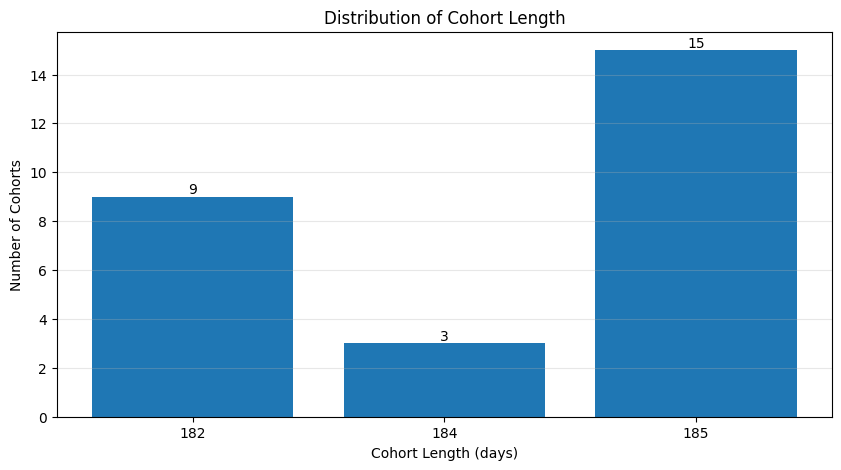

In [79]:
dist = (
    cohort_length['cohort_length']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    dist.index.astype(str),
    dist.values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.xlabel('Cohort Length (days)')
plt.ylabel('Number of Cohorts')
plt.title('Distribution of Cohort Length')
plt.grid(axis='y', alpha=0.3)

plt.show()

Distribution of running revenue per cohort

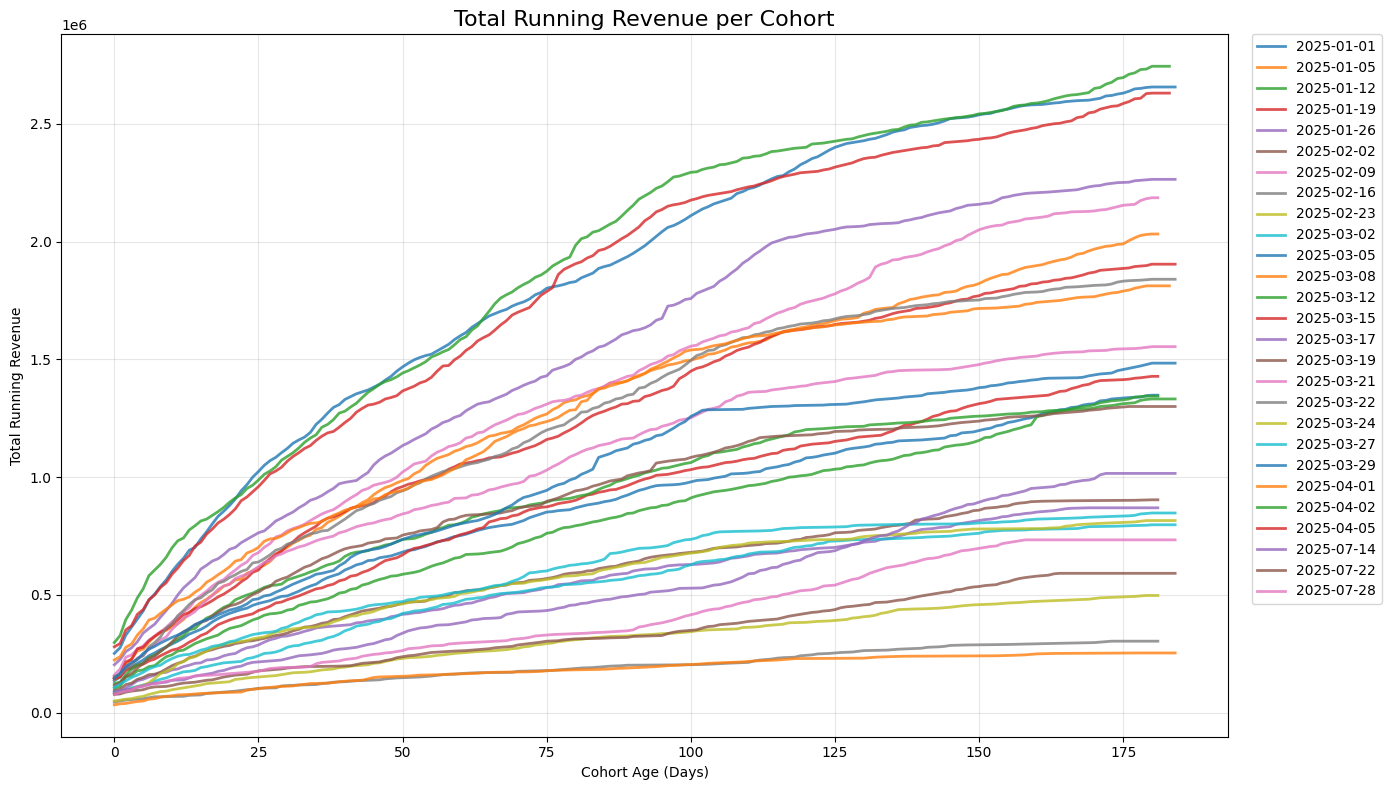

In [80]:
import matplotlib.pyplot as plt

sample = (
    df["date_created_at"]
    .drop_duplicates()
    .sample(min(30, df["date_created_at"].nunique()), random_state=42)
)

plt.figure(figsize=(14, 8))

for cohort in sorted(sample):

    temp = (
        df[df["date_created_at"] == cohort]
        .groupby("cohort_age", as_index=False)["revenue_running_total"]
        .sum()
        .sort_values("cohort_age")
    )

    plt.plot(
        temp["cohort_age"],
        temp["revenue_running_total"],
        linewidth=2,
        alpha=0.8,
        label=cohort.strftime("%Y-%m-%d")
    )

plt.title("Total Running Revenue per Cohort", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Total Running Revenue")
plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

Average revenue daily push distribution per-cohort age per-adnet

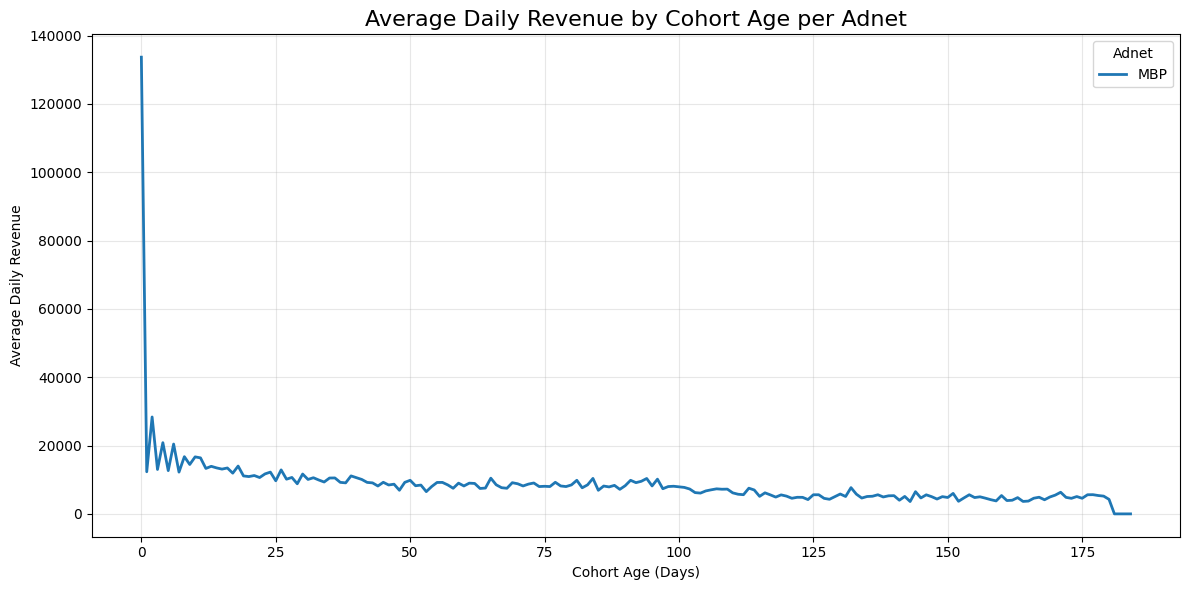

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for adnet, temp in (
    df.groupby("adnet")
):

    avg_daily = (
        temp
        .groupby("cohort_age")["revenue_dailypush"]
        .mean()
    )

    plt.plot(
        avg_daily.index,
        avg_daily.values,
        linewidth=2,
        label=adnet
    )

plt.title("Average Daily Revenue by Cohort Age per Adnet", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Average Daily Revenue")
plt.grid(alpha=0.3)
plt.legend(title="Adnet")

plt.tight_layout()
plt.show()

Average total revenue distribution per cohort age

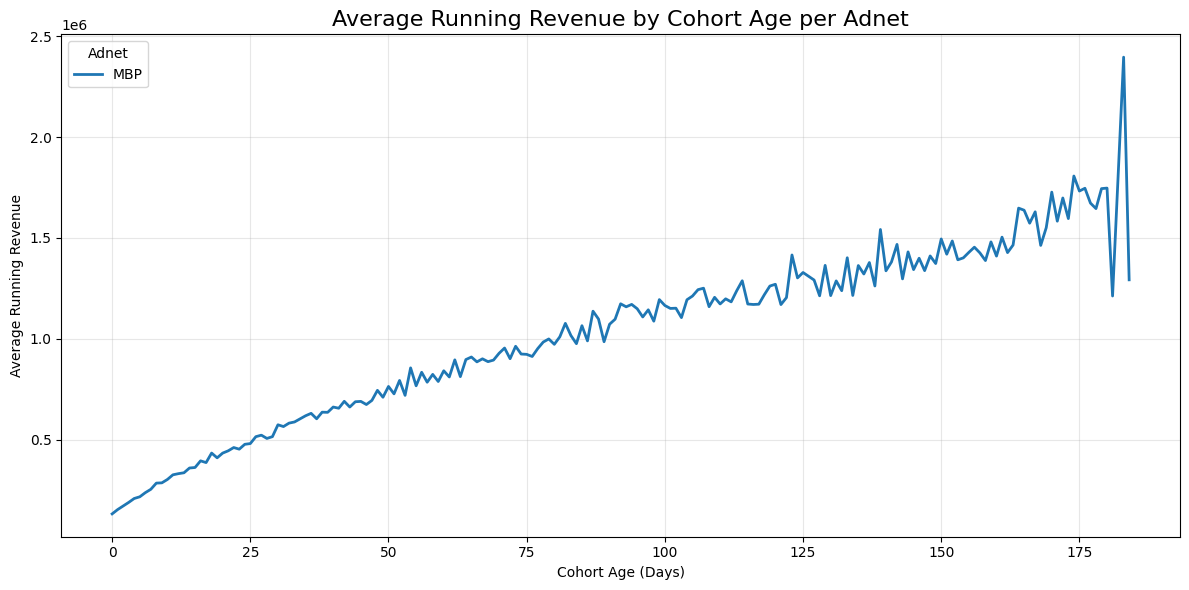

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for adnet, temp in df.groupby("adnet"):

    avg_running = (
        temp
        .groupby("cohort_age")["revenue_running_total"]
        .mean()
    )

    plt.plot(
        avg_running.index,
        avg_running.values,
        linewidth=2,
        label=adnet
    )

plt.title("Average Running Revenue by Cohort Age per Adnet", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Average Running Revenue")
plt.grid(alpha=0.3)
plt.legend(title="Adnet")

plt.tight_layout()
plt.show()

Numerical correlation

<Axes: >

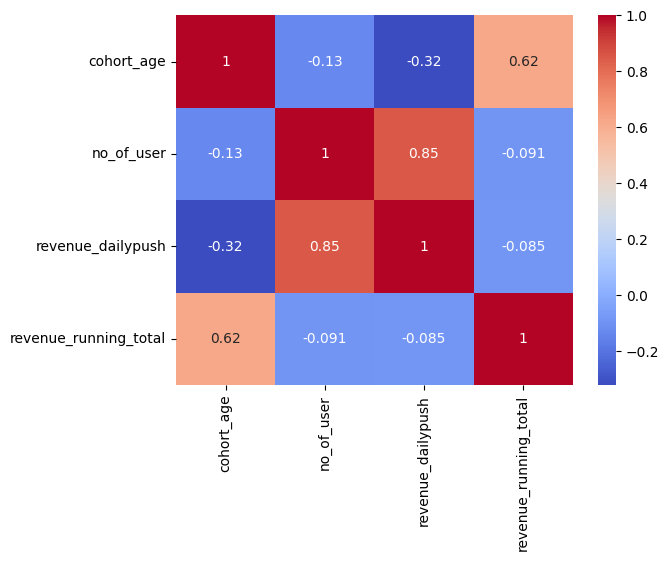

In [83]:
numeric_cols = [
    'cohort_age',
    'no_of_user',
    'revenue_dailypush',
    'revenue_running_total'
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

## Preprocessing

### Sort Data

Final preparation with sorting date created and cohort age

In [84]:
df = (
    df
    .sort_values(
        ['date_created_at', 'cohort_age']
    )
    .reset_index(drop=True)
)

In [85]:
df.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age
0,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0
1,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1
2,2025-01-01,MBP,2025-01-03,18,36000.0,DAILYPUSH,188000.0,2
3,2025-01-01,MBP,2025-01-04,4,8000.0,DAILYPUSH,196000.0,3
4,2025-01-01,MBP,2025-01-05,7,14000.0,DAILYPUSH,210000.0,4


### Feature Selection

Selecting feature for new dataframe

In [86]:
KEEP_COLS = [
    'date_created_at',
    'adnet',
    'cohort_age',
    'revenue_dailypush',
    'revenue_running_total',
]

df_model = df[KEEP_COLS].copy()

In [87]:
df_model.head()

,date_created_at,adnet,cohort_age,revenue_dailypush,revenue_running_total
0,2025-01-01,MBP,0,136000.0,136000.0
1,2025-01-01,MBP,1,16000.0,152000.0
2,2025-01-01,MBP,2,36000.0,188000.0
3,2025-01-01,MBP,3,8000.0,196000.0
4,2025-01-01,MBP,4,14000.0,210000.0


### Continuity Check & Gap Filling

TimesFM ignores `cohort_age` itself — it assumes every element of the input array is one evenly-spaced step (1 day). Missing days must therefore be filled so the series stays aligned.

Here the model target is **daily** revenue, so a missing day means **no revenue that day → 0**. We reindex each (cohort, adnet) series onto a gap-free daily grid, fill `revenue_dailypush` with 0, and forward-fill `revenue_running_total` (the cumulative value carries over).

In [88]:
# def count_gaps(data, group_cols=("date_created_at", "adnet"), age_col="cohort_age"):
#     """List (cohort, adnet) series whose cohort_age is not a continuous range."""
#     rows = []
#     for keys, g in data.groupby(list(group_cols)):
#         span = int(g[age_col].max() - g[age_col].min() + 1)
#         missing = span - g[age_col].nunique()
#         if missing > 0:
#             keys = keys if isinstance(keys, tuple) else (keys,)
#             rows.append((*keys, missing))
#     return rows

# gaps = count_gaps(df_model)
# print("Series with gaps:", len(gaps))
# for r in gaps[:20]:
#     print(r)

In [89]:
# def make_continuous(data,
#                     group_cols=("date_created_at", "adnet"),
#                     age_col="cohort_age",
#                     daily_col="revenue_dailypush",
#                     running_col="revenue_running_total"):
#     """
#     Reindex each (cohort, adnet) series onto a gap-free daily grid
#     (cohort_age 0..max) so TimesFM sees an evenly-spaced series.

#     Daily revenue on a missing day is 0; the running total is
#     forward-filled (and leading gaps set to 0).
#     """
#     group_cols = list(group_cols)
#     out = []

#     for keys, g in data.groupby(group_cols):
#         g = g.sort_values(age_col)
#         full = range(0, int(g[age_col].max()) + 1)

#         g = g.set_index(age_col).reindex(full)

#         keys = keys if isinstance(keys, tuple) else (keys,)
#         for col, val in zip(group_cols, keys):
#             g[col] = val

#         g[daily_col] = g[daily_col].fillna(0.0)
#         g[running_col] = g[running_col].ffill().fillna(0.0)

#         out.append(g.reset_index())

#     return pd.concat(out, ignore_index=True)

# df_model = make_continuous(df_model)

# print("Gaps remaining after fill:", len(count_gaps(df_model)))
# df_model.head()

### Split Data

Split to train 80% and validation 20% from total cohorts

In [90]:
cohorts = sorted(df_model['date_created_at'].unique())

split_idx = int(len(cohorts) * 0.8)

train_cohorts = cohorts[:split_idx]
val_cohorts = cohorts[split_idx:]

In [91]:
print("Total Train Cohort:", len(train_cohorts))
print("Sample Train Cohort:", train_cohorts)

print("Total Val Cohort:", len(val_cohorts))
print("Sample Val Cohort:", val_cohorts)

Total Train Cohort: 21
Sample Train Cohort: [datetime.date(2025, 1, 1), datetime.date(2025, 1, 5), datetime.date(2025, 1, 12), datetime.date(2025, 1, 19), datetime.date(2025, 1, 26), datetime.date(2025, 2, 2), datetime.date(2025, 2, 9), datetime.date(2025, 2, 16), datetime.date(2025, 2, 23), datetime.date(2025, 3, 2), datetime.date(2025, 3, 5), datetime.date(2025, 3, 8), datetime.date(2025, 3, 12), datetime.date(2025, 3, 15), datetime.date(2025, 3, 17), datetime.date(2025, 3, 19), datetime.date(2025, 3, 21), datetime.date(2025, 3, 22), datetime.date(2025, 3, 24), datetime.date(2025, 3, 27), datetime.date(2025, 3, 29)]
Total Val Cohort: 6
Sample Val Cohort: [datetime.date(2025, 4, 1), datetime.date(2025, 4, 2), datetime.date(2025, 4, 5), datetime.date(2025, 7, 14), datetime.date(2025, 7, 22), datetime.date(2025, 7, 28)]


Insert to pandas for next step (forecasting)

In [92]:
train_df = df_model[df_model['date_created_at'].isin(train_cohorts)]
val_df = df_model[df_model['date_created_at'].isin(val_cohorts)]

In [93]:
print("Total Cohorts Train:", train_df["date_created_at"].nunique())
print("")
print("Total Adnets:", train_df["adnet"].nunique())
print(train_df["adnet"].unique())
print("")
print("Total Cohorts per Adnet:", train_df.groupby("adnet")["date_created_at"].nunique())

Total Cohorts Train: 21

Total Adnets: 1
['MBP']

Total Cohorts per Adnet: adnet
MBP    21
Name: date_created_at, dtype: int64


In [94]:
print("Total Cohorts Val:", val_df["date_created_at"].nunique())
print("")
print("Total Adnets:", val_df["adnet"].nunique())
print(val_df["adnet"].unique())
print("")
print("Total Cohorts per Adnet:", val_df.groupby("adnet")["date_created_at"].nunique())

Total Cohorts Val: 6

Total Adnets: 1
['MBP']

Total Cohorts per Adnet: adnet
MBP    6
Name: date_created_at, dtype: int64


### Target

Setup feature and target for training

In [95]:
# Model forecasts the daily series; running total is reconstructed for reporting.
TARGET = 'revenue_dailypush'
RUNNING = 'revenue_running_total'

TimesFM is a univariate, zero-shot model. It consumes the ordered `revenue_dailypush` series directly (no scaling). `revenue_running_total` is retained only to anchor the cumulative reconstruction and to compare against the actual LTV curve.

Checking data train

In [96]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3186 entries, 0 to 3185
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_created_at        3186 non-null   dbdate 
 1   adnet                  3186 non-null   object 
 2   cohort_age             3186 non-null   int64  
 3   revenue_dailypush      3186 non-null   float64
 4   revenue_running_total  3186 non-null   float64
dtypes: dbdate(1), float64(2), int64(1), object(1)
memory usage: 149.3+ KB


In [97]:
train_df.head()

,date_created_at,adnet,cohort_age,revenue_dailypush,revenue_running_total
0,2025-01-01,MBP,0,136000.0,136000.0
1,2025-01-01,MBP,1,16000.0,152000.0
2,2025-01-01,MBP,2,36000.0,188000.0
3,2025-01-01,MBP,3,8000.0,196000.0
4,2025-01-01,MBP,4,14000.0,210000.0


Checking data validation

In [98]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 935 entries, 3186 to 4120
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_created_at        935 non-null    dbdate 
 1   adnet                  935 non-null    object 
 2   cohort_age             935 non-null    int64  
 3   revenue_dailypush      935 non-null    float64
 4   revenue_running_total  935 non-null    float64
dtypes: dbdate(1), float64(2), int64(1), object(1)
memory usage: 43.8+ KB


In [99]:
val_df.head()

,date_created_at,adnet,cohort_age,revenue_dailypush,revenue_running_total
3186,2025-04-01,MBP,0,224000.0,224000.0
3187,2025-04-01,MBP,1,14000.0,238000.0
3188,2025-04-01,MBP,2,40000.0,278000.0
3189,2025-04-01,MBP,3,14000.0,292000.0
3190,2025-04-01,MBP,4,38000.0,330000.0


## Forecast Setup

### Series Builder

Helpers to pull an ordered series for one (cohort, adnet). `get_series` returns the daily target by default; pass `col=RUNNING` to get the running total used as the reconstruction baseline.

In [100]:
CONTEXT_LEN = 2048   # max context length (2.5 supports up to 16k)
HORIZON_LEN = 512    # max forecast horizon per call
CONTEXT_MIN = 30     # minimum history required before forecasting
# Note: TimesFM 2.5 removed the frequency indicator — no FREQ needed

def get_frame(data, cohort, adnet):
    """Sorted rows for one (cohort, adnet)."""
    return (
        data[
            (data["date_created_at"] == cohort) &
            (data["adnet"] == adnet)
        ]
        .sort_values("cohort_age")
    )

def get_series(data, cohort, adnet, col=None):
    """Ordered univariate series; defaults to the daily TARGET."""
    col = col or TARGET
    return get_frame(data, cohort, adnet)[col].to_numpy(dtype=float)

def reconstruct_running(seed_running_last, daily_future):
    """Cumulative running total over the horizon from a daily forecast."""
    return seed_running_last + np.cumsum(np.asarray(daily_future, dtype=float))

## Modeling

### TimesFM

TimesFM is a pretrained foundation model, so it is used zero-shot — there is no training loop. Load the 2.5 200M PyTorch checkpoint with the fixed architecture parameters.

In [101]:
import torch
import timesfm

torch.set_float32_matmul_precision("high")

# TimesFM 2.5 – 200M parameter checkpoint (PyTorch)
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

tfm.compile(
    timesfm.ForecastConfig(
        max_context=CONTEXT_LEN,
        max_horizon=HORIZON_LEN,
        normalize_inputs=True,
        use_continuous_quantile_head=False,   # point forecast only
        force_flip_invariance=False,
        infer_is_positive=True,               # revenue is always >= 0
        fix_quantile_crossing=True,
    )
)

## Evaluation

### Visualization

Evaluate zero-shot on the validation cohorts in **running-total space**: forecast the daily tail, rebuild the cumulative curve from the last seed day, and compare against the actual running total.

In [102]:
EVAL_HORIZON = 30

eval_contexts = []
eval_baselines = []
eval_actual_running = []

evaluated_series = []

for cohort in val_cohorts:

    adnets = (
        val_df.loc[
            val_df["date_created_at"] == cohort,
            "adnet"
        ]
        .unique()
    )

    for adnet in adnets:

        daily = get_series(val_df, cohort, adnet)
        running = get_series(val_df, cohort, adnet, col=RUNNING)

        if len(daily) < CONTEXT_MIN + EVAL_HORIZON:
            continue

        ctx = daily[:-EVAL_HORIZON]

        eval_contexts.append(ctx)
        eval_baselines.append(running[len(ctx) - 1])     # last seed running total
        eval_actual_running.append(running[-EVAL_HORIZON:])

        evaluated_series.append((cohort, adnet))

print("Evaluated series:", len(eval_contexts))

point_forecast, _ = tfm.forecast(
    horizon=EVAL_HORIZON,
    inputs=eval_contexts,
)

pred_running = [
    reconstruct_running(
        eval_baselines[i],
        point_forecast[i, :EVAL_HORIZON],
    )
    for i in range(len(eval_contexts))
]

y_pred = np.concatenate(pred_running)
y_val = np.concatenate(eval_actual_running)

Evaluated series: 6


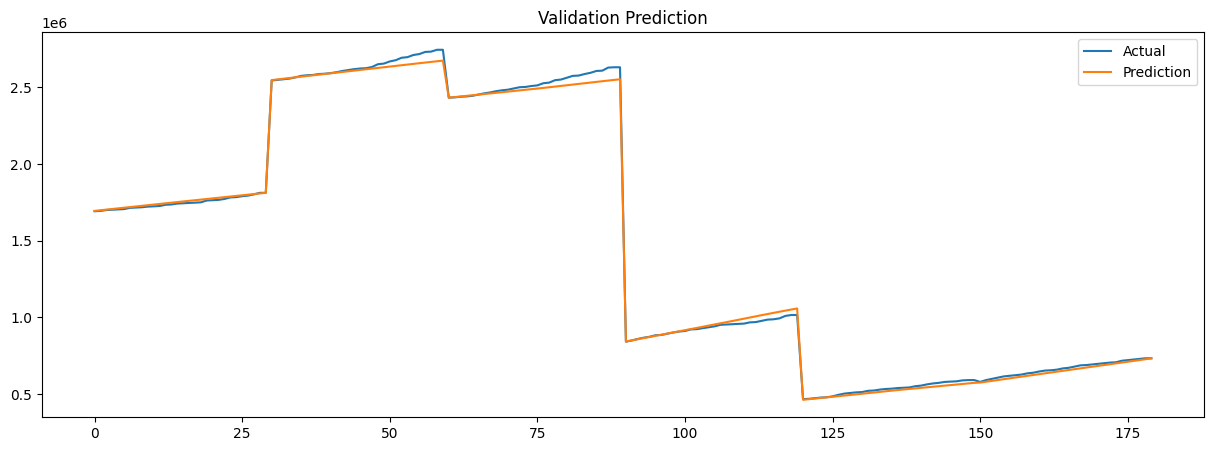

In [103]:
plt.figure(figsize=(15,5))

plt.plot(
    y_val[:200],
    label='Actual'
)

plt.plot(
    y_pred[:200],
    label='Prediction'
)

plt.title('Validation Prediction')

plt.legend()

plt.show()

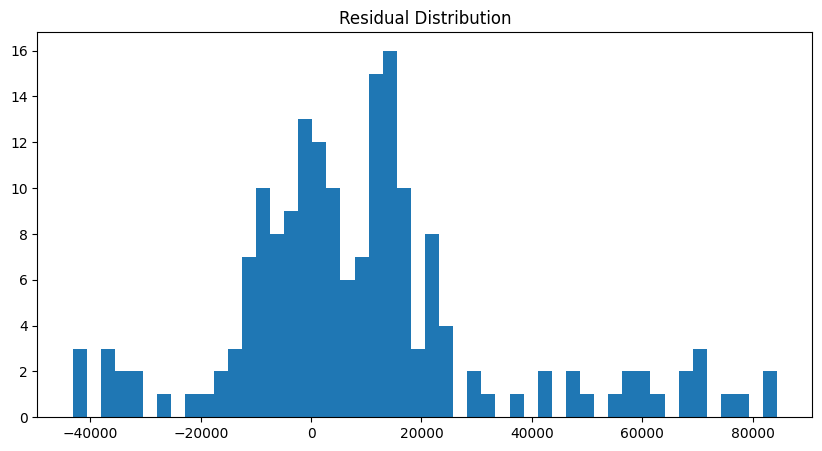

In [104]:
residuals = y_val - y_pred

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=50
)

plt.title('Residual Distribution')

plt.show()

### Metrics

Detail evaluation metrics in MAE, RMSE, MAPE

In [105]:
mae = mean_absolute_error(
    y_val,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred
    )
)

mape = mean_absolute_percentage_error(
    y_val,
    y_pred
) * 100

In [106]:
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 17863.223458
RMSE : 25839.711341
MAPE : 1.45%


## Projection

Use the first `SEED_DAYS` of a cohort as context, forecast the remaining **daily** revenue in one call, then rebuild the running total so the final day reports the projected LTV.

Select cohort and run projection

In [107]:
candidates = [
    c for c in val_cohorts
    if int(
        df_model[df_model["date_created_at"] == c]["cohort_age"].max()
    ) >= SEED_DAYS
]

print("Eligible cohorts:", len(candidates))

# Pilih cohort
cohort = candidates[1]

# Lihat adnet yang tersedia pada cohort tersebut
available_adnets = (
    df_model.loc[
        df_model["date_created_at"] == cohort,
        "adnet"
    ]
    .unique()
)

print("Available Adnets:", available_adnets)

adnet = available_adnets[0]

cohort_raw = get_frame(df_model, cohort, adnet).reset_index(drop=True)

seed_mask = cohort_raw["cohort_age"] < SEED_DAYS

# Daily series (model space)
context = cohort_raw.loc[seed_mask, TARGET].values.astype(float)
actual_daily_future = cohort_raw.loc[~seed_mask, TARGET].values.astype(float)

# Running totals (reporting space)
seed_running = cohort_raw.loc[seed_mask, RUNNING].values.astype(float)
actual_future = cohort_raw.loc[~seed_mask, RUNNING].values.astype(float)

n_steps = len(actual_daily_future)

print("Cohort      :", cohort)
print("Adnet       :", adnet)
print("Seed days   :", len(context))
print("Future days :", n_steps)

# Forecast daily, then rebuild running total
point_forecast, _ = tfm.forecast(
    horizon=n_steps,
    inputs=[context],
)

pred_daily_future = point_forecast[0, :n_steps]
baseline = seed_running[-1] if len(seed_running) else 0.0
pred_future = reconstruct_running(baseline, pred_daily_future)

print(
    f"Predicted running total at day "
    f"{SEED_DAYS + n_steps - 1}: "
    f"{pred_future[-1]:,.0f}"
)

print(
    f"Actual    running total at day "
    f"{SEED_DAYS + n_steps - 1}: "
    f"{actual_future[-1]:,.0f}"
)

Eligible cohorts: 6
Available Adnets: ['MBP']
Cohort      : 2025-04-02
Adnet       : MBP
Seed days   : 60
Future days : 118
Predicted running total at day 177: 3,195,609
Actual    running total at day 177: 2,744,000


Actual vs projection visualization

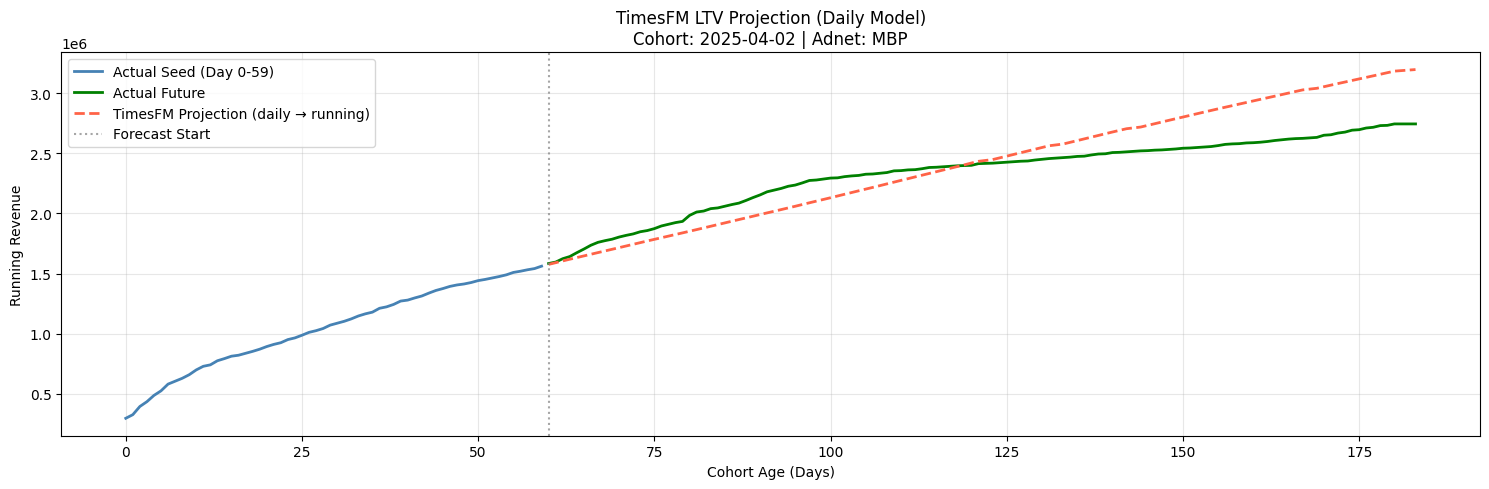

In [108]:
seed_age = cohort_raw.loc[seed_mask, "cohort_age"].values
future_age = cohort_raw.loc[~seed_mask, "cohort_age"].values[:n_steps]
pred_age = future_age[:len(pred_future)]

plt.figure(figsize=(15, 5))

plt.plot(
    seed_age,
    seed_running,
    label=f"Actual Seed (Day 0-{SEED_DAYS-1})",
    color="steelblue",
    linewidth=2
)

plt.plot(
    future_age,
    actual_future,
    label="Actual Future",
    color="green",
    linewidth=2
)

plt.plot(
    pred_age,
    pred_future,
    label="TimesFM Projection (daily → running)",
    color="tomato",
    linestyle="--",
    linewidth=2
)

plt.axvline(
    x=SEED_DAYS,
    color="gray",
    linestyle=":",
    alpha=0.7,
    label="Forecast Start"
)

plt.title(
    f"TimesFM LTV Projection (Daily Model)\n"
    f"Cohort: {str(cohort)[:10]} | Adnet: {adnet}"
)

plt.xlabel("Cohort Age (Days)")
plt.ylabel("Running Revenue")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Testing on Unseen Data

This section evaluates TimesFM on a completely hold-out dataset (`linkit-rnd-475909.country_summary.ml_lstm_unseen_5cohorts`) containing 5 unseen cohorts that the model has never been exposed to.

Because TimesFM is a **univariate, zero-shot** foundation model, the unseen data needs only minimal preparation: load the raw table, derive `cohort_age` (used to order the series and slice seed/horizon), and sort. No scaler or encoder is fit, no scaling is applied, and `day_of_week` / encodings are not needed — the model consumes the raw `revenue_running_total` series directly.

### Loader

Query the unseen testing table from Google BigQuery

In [109]:
# df_unseen = pd.read_gbq(unseen_query, project_id=project_id, dialect='standard')
# df_unseen.head()

df_unseen = unseen_raw.copy()

### Feature Engineering

Derive `cohort_age` and sort the same way as the training data. Scaling, encoding, and `day_of_week` are intentionally skipped since TimesFM only uses the ordered target series.

In [110]:
df_unseen['date_created_at'] = pd.to_datetime(df_unseen['date_created_at'])
df_unseen['date_update']     = pd.to_datetime(df_unseen['date_update'])

df_unseen['cohort_age'] = (
    df_unseen['date_update'] - df_unseen['date_created_at']
).dt.days

df_unseen = (
    df_unseen
    .sort_values(['date_created_at', 'cohort_age'])
    .reset_index(drop=True)
)

df_unseen.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age
0,2025-08-02,MBP,2025-08-02,1768,198000.0,FIRSTPUSH,198000.0,0
1,2025-08-02,MBP,2025-08-03,4,8000.0,DAILYPUSH,206000.0,1
2,2025-08-02,MBP,2025-08-04,10,20000.0,DAILYPUSH,226000.0,2
3,2025-08-02,MBP,2025-08-05,7,14000.0,DAILYPUSH,240000.0,3
4,2025-08-02,MBP,2025-08-06,5,10000.0,DAILYPUSH,250000.0,4


Apply the same gap-filling so the unseen series are also evenly spaced.

In [111]:
df_unseen = make_continuous(df_unseen)

print("Unseen gaps remaining after fill:", len(count_gaps(df_unseen)))
df_unseen.head()

Unseen gaps remaining after fill: 0


,cohort_age,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
0,0,2025-08-02,MBP,2025-08-02,1768,198000.0,FIRSTPUSH,198000.0
1,1,2025-08-02,MBP,2025-08-03,4,8000.0,DAILYPUSH,206000.0
2,2,2025-08-02,MBP,2025-08-04,10,20000.0,DAILYPUSH,226000.0
3,3,2025-08-02,MBP,2025-08-05,7,14000.0,DAILYPUSH,240000.0
4,4,2025-08-02,MBP,2025-08-06,5,10000.0,DAILYPUSH,250000.0


Checking unseen cohorts and their length

In [112]:
unseen_cohorts = sorted(df_unseen["date_created_at"].unique())

print("Total unseen cohorts:", len(unseen_cohorts))

for cohort in unseen_cohorts:

    print(f"\nCohort: {str(cohort)[:10]}")

    temp = (
        df_unseen[
            df_unseen["date_created_at"] == cohort
        ]
        .groupby("adnet")["cohort_age"]
        .max()
        .sort_index()
    )

    for adnet, max_age in temp.items():
        print(f"  {adnet:<6} -> {int(max_age)+1} days")

Total unseen cohorts: 3

Cohort: 2025-08-02
  MBP    -> 185 days

Cohort: 2025-08-06
  MBP    -> 185 days

Cohort: 2025-08-10
  MBP    -> 185 days


### Visualization

Distribution of running revenue per cohort

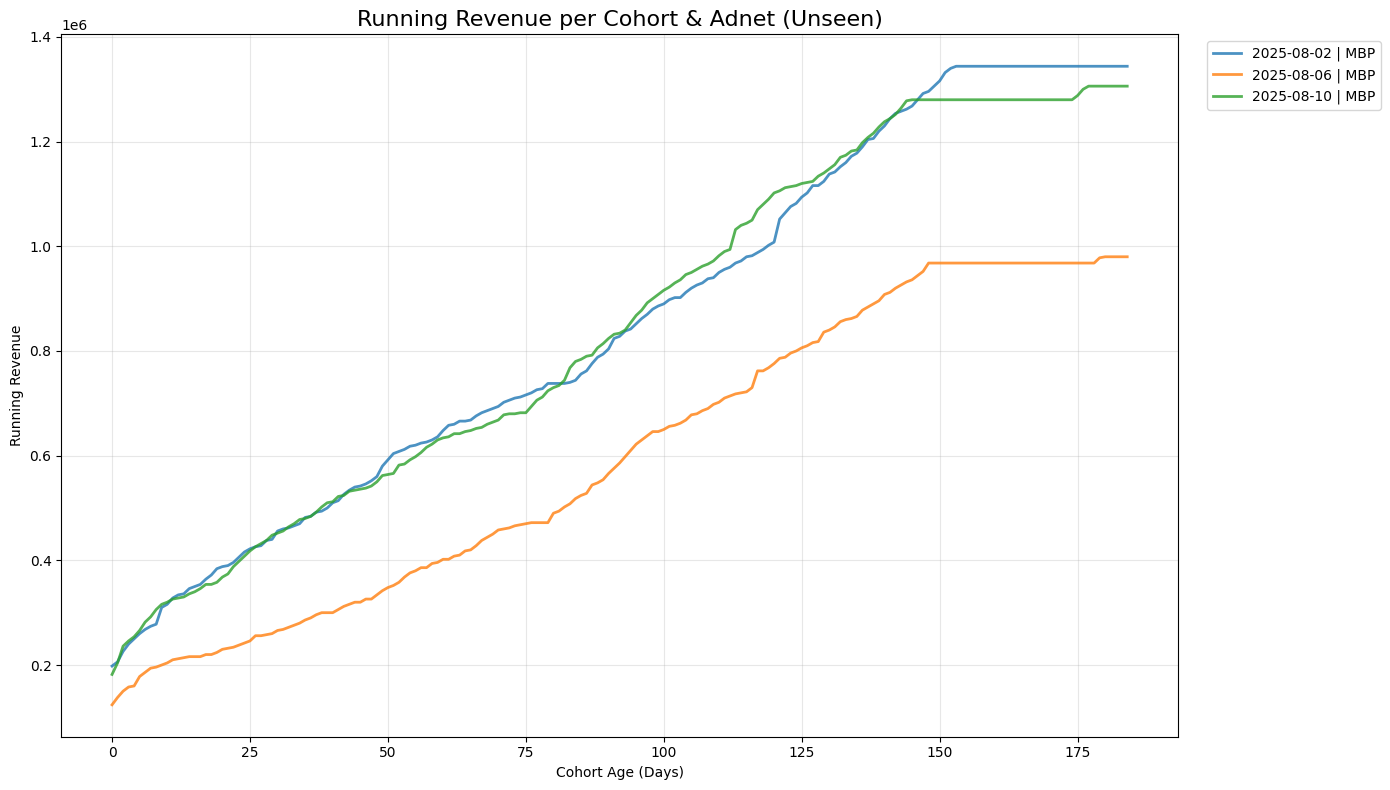

In [113]:
plt.figure(figsize=(14, 8))

for (cohort, adnet), temp in (
    df_unseen
    .groupby(["date_created_at", "adnet"])
):

    temp = temp.sort_values("cohort_age")

    plt.plot(
        temp["cohort_age"],
        temp["revenue_running_total"],
        linewidth=2,
        alpha=0.8,
        label=f"{pd.Timestamp(cohort).strftime('%Y-%m-%d')} | {adnet}"
    )

plt.title("Running Revenue per Cohort & Adnet (Unseen)", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Running Revenue")

plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Forecast

For each unseen cohort, seed with the first `SEED_DAYS` days, forecast the remaining **daily** revenue, and rebuild the running total. Metrics and plots are in running-revenue space.

In [114]:
def project_cohort(cohort_raw, seed_len):
    """
    Project LTV for one (cohort, adnet) series using TimesFM on the daily
    series, then reconstruct the running total.

    Returns a dict with both daily and running arrays.
    """
    seed_mask = cohort_raw["cohort_age"] < seed_len

    context = cohort_raw.loc[seed_mask, TARGET].values.astype(float)
    actual_daily_future = cohort_raw.loc[~seed_mask, TARGET].values.astype(float)

    seed_running = cohort_raw.loc[seed_mask, RUNNING].values.astype(float)
    actual_running_future = cohort_raw.loc[~seed_mask, RUNNING].values.astype(float)

    n_steps = len(actual_daily_future)

    point_forecast, _ = tfm.forecast(
        horizon=n_steps,
        inputs=[context],
    )

    pred_daily_future = point_forecast[0, :n_steps]
    baseline = seed_running[-1] if len(seed_running) else 0.0
    pred_running_future = reconstruct_running(baseline, pred_daily_future)

    return {
        "seed_running": seed_running,
        "context": context,
        "actual_future": actual_running_future,
        "pred_future": pred_running_future,
        "actual_daily_future": actual_daily_future,
        "pred_daily_future": pred_daily_future,
        "n_steps": n_steps,
    }

In [115]:
results = {}

for (cohort, adnet), cohort_raw in (
    df_unseen
    .groupby(["date_created_at", "adnet"])
):

    cohort_raw = (
        cohort_raw
        .sort_values("cohort_age")
        .reset_index(drop=True)
    )

    if len(cohort_raw) < 2:
        continue

    seed_len = min(SEED_DAYS, len(cohort_raw) - 1)

    r = project_cohort(cohort_raw, seed_len)
    r["cohort_raw"] = cohort_raw
    r["adnet"] = adnet
    r["seed_len"] = seed_len

    results[(cohort, adnet)] = r

    mape_full = (
        mean_absolute_percentage_error(
            r["actual_future"],
            r["pred_future"]
        ) * 100
    )

    print(
        f"{str(cohort)[:10]} | {adnet:<6} "
        f"seed={seed_len:>2}d "
        f"forecast={r['n_steps']:>3}d "
        f"| final pred={r['pred_future'][-1]:>12,.0f} "
        f"actual={r['actual_future'][-1]:>12,.0f} "
        f"MAPE={mape_full:.2f}%"
    )

2025-08-02 | MBP    seed=60d forecast=125d | final pred=   1,248,524 actual=   1,344,000 MAPE=8.30%
2025-08-06 | MBP    seed=60d forecast=125d | final pred=     818,470 actual=     980,000 MAPE=15.48%
2025-08-10 | MBP    seed=60d forecast=125d | final pred=   1,349,308 actual=   1,306,000 MAPE=4.38%


Actual vs projection visualization for each unseen cohort

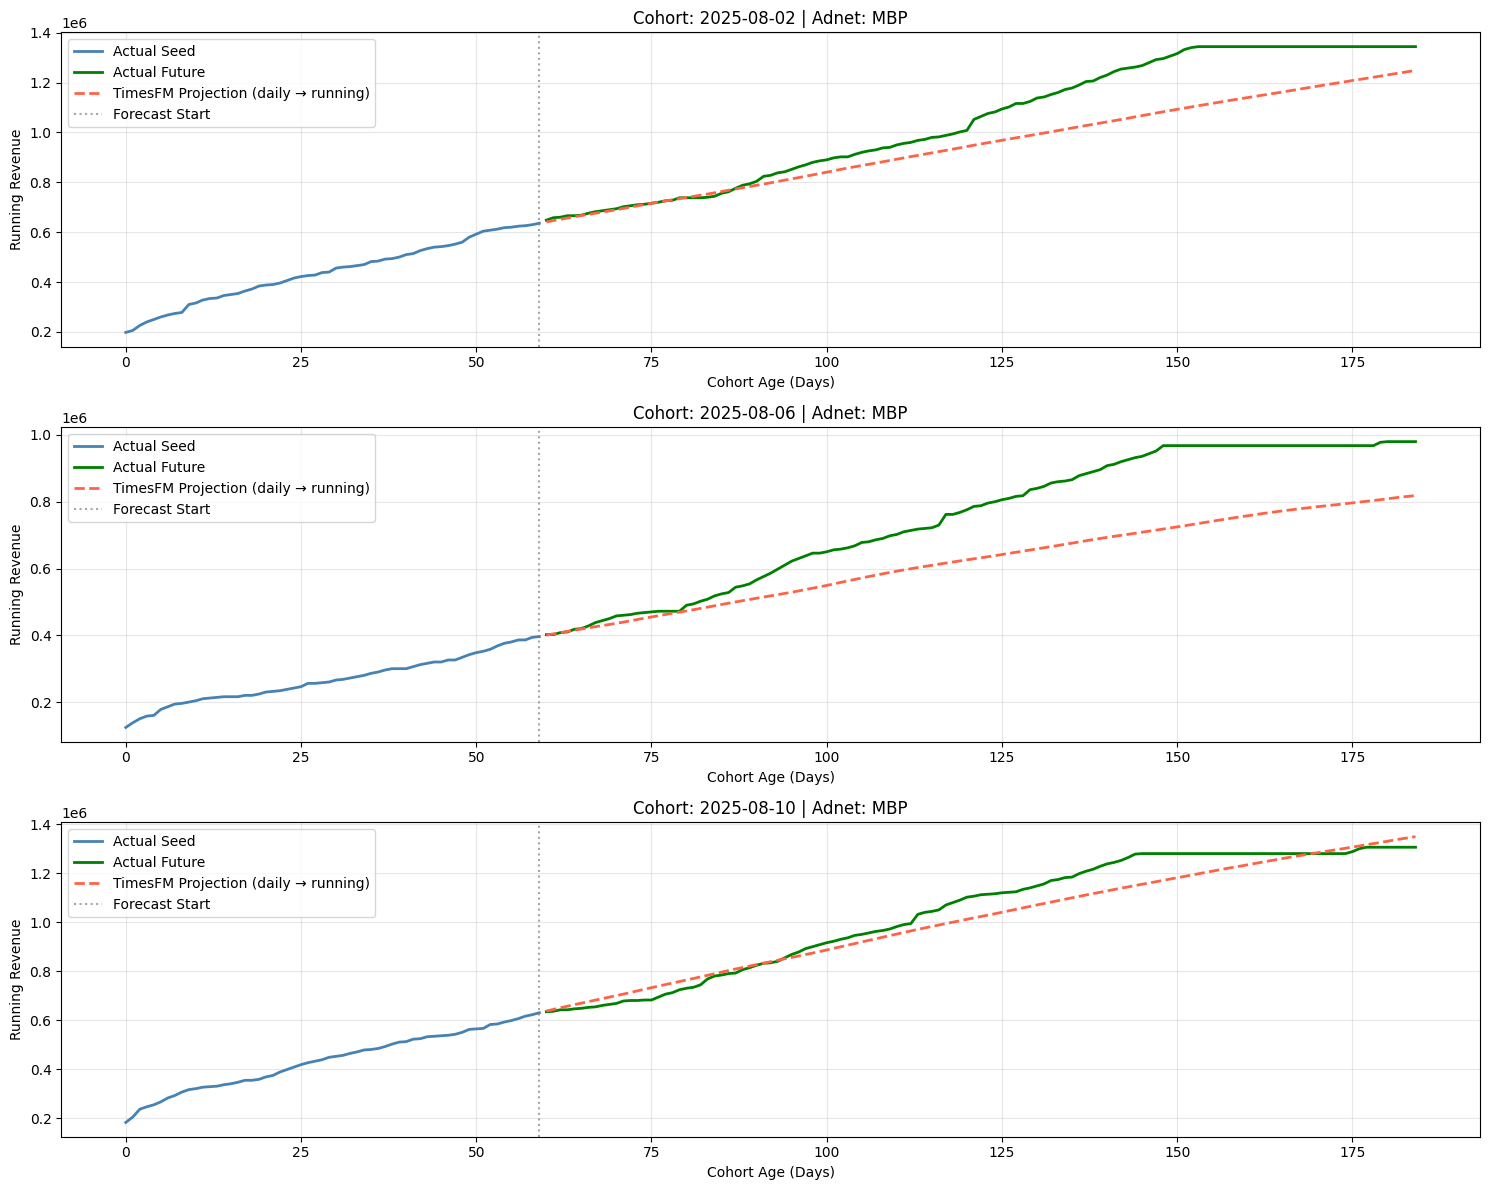

In [116]:
n_series = len(results)

fig, axes = plt.subplots(
    n_series,
    1,
    figsize=(15, 4 * n_series)
)

if n_series == 1:
    axes = [axes]

for ax, ((cohort, adnet), r) in zip(axes, results.items()):

    cohort_raw = r["cohort_raw"]
    seed_len = r["seed_len"]
    n_steps = r["n_steps"]

    seed_mask = cohort_raw["cohort_age"] < seed_len

    ages = cohort_raw["cohort_age"].values

    seed_age = ages[seed_mask]
    future_age = ages[~seed_mask][:n_steps]
    pred_age = future_age[:len(r["pred_future"])]

    ax.plot(
        seed_age,
        r["seed_running"],
        label="Actual Seed",
        color="steelblue",
        linewidth=2
    )

    ax.plot(
        future_age,
        r["actual_future"],
        label="Actual Future",
        color="green",
        linewidth=2
    )

    ax.plot(
        pred_age,
        r["pred_future"],
        label="TimesFM Projection (daily → running)",
        color="tomato",
        linestyle="--",
        linewidth=2
    )

    if len(seed_age) > 0:
        ax.axvline(
            x=seed_age[-1],
            color="gray",
            linestyle=":",
            alpha=0.7,
            label="Forecast Start"
        )

    ax.set_title(
        f"Cohort: {str(cohort)[:10]} | Adnet: {adnet}"
    )

    ax.set_xlabel("Cohort Age (Days)")
    ax.set_ylabel("Running Revenue")

    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()